In [68]:
using Unitful
using Plots
using Measures

gr()

Plots.GRBackend()

In [157]:
grid_size = ["default",0.5u"mm", 0.45u"mm", 0.4u"mm", 0.35u"mm", 0.3u"mm", 0.25u"mm", 0.2u"mm", 0.15u"mm",  0.1u"mm", 0.05u"mm", 0.02u"mm", 0.01u"mm", 0.01u"mm"]
min_pot =  [0.9986997, 0.9981574, 0.9975947, 0.9982155,0.9979807, 0.99515855,  0.9961249, 0.9980359, 0.99687743, 0.9974885, 0.9974979, 0.9916288, 0.65598214, 0.990133]

14-element Vector{Float64}:
 0.9986997
 0.9981574
 0.9975947
 0.9982155
 0.9979807
 0.99515855
 0.9961249
 0.9980359
 0.99687743
 0.9974885
 0.9974979
 0.9916288
 0.65598214
 0.990133

In [169]:
using Statistics
r = min_pot ./ 1  # residui normlaizzati

res = min_pot .- 1              # residui centrati a 0
σ = std(res)                    # deviazione standard
res_σ = res ./ σ                # residui normalizzati in unità di sigma
var_pct = 100 .* (min_pot .- 1)


14-element Vector{Float64}:
  -0.1300300000000032
  -0.18426000000000275
  -0.24053000000000546
  -0.17844999999999667
  -0.2019299999999946
  -0.4841450000000025
  -0.387510000000002
  -0.19641000000000242
  -0.31225700000000467
  -0.25115
  -0.25020999999999516
  -0.8371200000000023
 -34.401786
  -0.9866999999999959

In [155]:
min_pot_old = [0.9916288, 0.65598214, ]
min_pot_new =  [0.9951849,0.9974032 ]

2-element Vector{Float64}:
 0.9951849
 0.9974032

In [168]:
100*(0.9916288-1)

-0.8371200000000023

In [164]:
 100 .* (min_pot_new .- 1)

2-element Vector{Float64}:
 -0.4815099999999961
 -0.25967999999999547

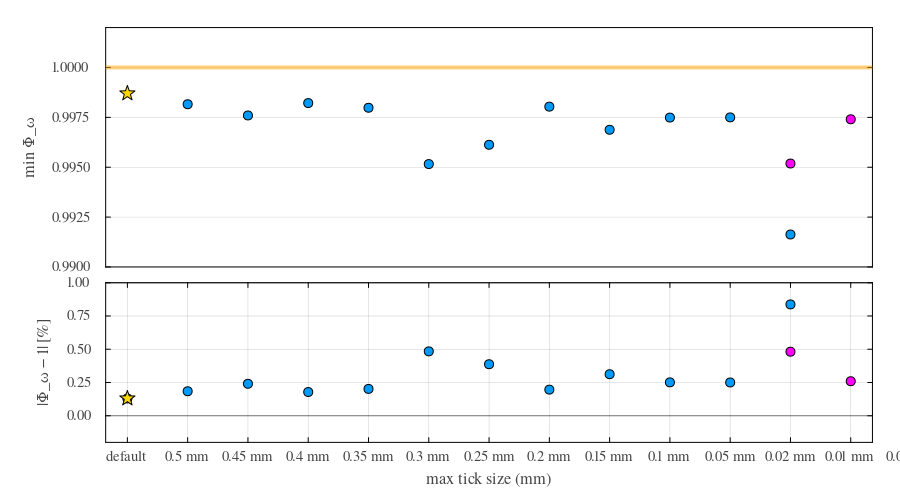

In [170]:
using Plots
using Colors

# Impostazioni "da paper"
default(
    fontfamily = "Times",
    guidefontsize = 10,
    tickfontsize = 9,
    legendfontsize = 9,
    titlefontsize = 10,
    lw = 1,
    ms = 5
)

x = 1:length(grid_size)
labels = string.(grid_size)



# Plot superiore
p1 = scatter(
    x[2:end-2],
    min_pot[2:end-2],
    markersize = 5,
    ylabel = "min Φ_ω",
    xticks = false,
    xlabel = "",
    legend = false,
    top_margin = 5mm,
    bottom_margin = 0mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)
ylims!(p1, 0.99, 1.002)
hline!(p1, [1.0], color=:orange, lw = 4 , alpha=0.5)
#plot!( [x[end-1]], [min_pot[end]], seriestype = :scatter, markercolor = :red, )

plot!( [x[1]], [min_pot[1]], seriestype = :scatter, marker = :star, markersize = 8, markercolor = :gold, )
plot!( [x[end-2],x[end-1]], [min_pot_new], seriestype = :scatter,  markercolor = :magenta, )

# Annotiamo il punto minimo
min_index = argmin(min_pot[1:end-2])

# Plot inferiore
p2 = scatter(
    x[1:end-2],
    abs.(var_pct[1:end-2]),
    markersize = 5,
    ylabel = "|Φ_ω − 1| [%]",
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = false,
    top_margin = 0mm,
    bottom_margin = 5mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)
ylims!(p2, -0.2, 1)
hline!(p2, [0.0], color=:black, lw = 1 , alpha=0.5)
hline!(p2, [1], color=:black, lw = 1 , alpha=0.5)
#plot!( [x[end-1]], [abs(var_pct[end])], seriestype = :scatter, markercolor = :orange, )

plot!( [x[1]], [abs.(var_pct[1])], seriestype = :scatter, marker = :star, markersize = 8, markercolor = :gold, )
plot!( [x[end-2],x[end-1]], [ abs.(100 .* (min_pot_new .- 1))], seriestype = :scatter,  markercolor = :magenta, )
# Layout verticale bilanciato senza gap
plot(
    p1,
    p2,
    layout = grid(
        2, 1,
        heights = [0.6, 0.4],
        hspace = 0mm
    ),
    link = :x, size = (900, 500)
)


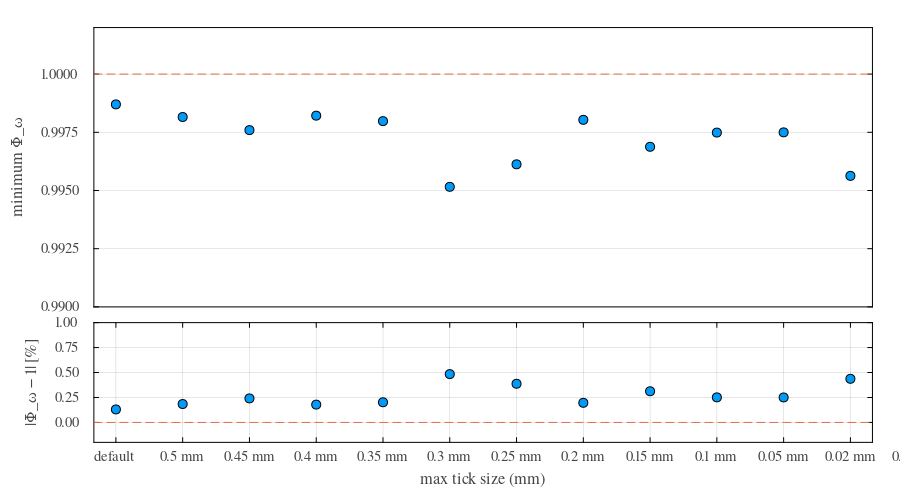

In [147]:


x = 1:length(grid_size)
labels = string.(grid_size)

# Plot superiore
p1 = plot(
    x[1:end-2],
    min_pot[1:end-2],
    seriestype = :scatter,
    ylabel = "minimum Φ_ω",
    xticks = false,
    xlabel = "",
    legend = false,
    top_margin = 5mm,       # solo margine superiore per bordo
    bottom_margin = 0mm,    # zero margine inferiore per attaccarlo al plot sotto
    left_margin = 5mm,
    right_margin = 5mm,
    framestyle = :box
)
ylims!(p1, 0.99, 1.002)
hline!(p1, [1.0], linestyle = :dash)
#plot!( [x[end-1]], [min_pot[end]], seriestype = :scatter, markercolor = :orange, )

# Plot inferiore
p2 = plot(
    x[1:end-2],
    abs.(var_pct[1:end-2]),
    seriestype = :scatter,
    ylabel = "|Φ_ω − 1| [%]",
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = false,
    top_margin = 0mm,       # zero margine superiore
    bottom_margin = 5mm,    # margine inferiore per bordo
    left_margin = 5mm,
    right_margin = 5mm,
    framestyle = :box
)
ylims!(p2, -0.2, 1)
hline!(p2, [0.0], linestyle = :dash)
# Layout verticale senza gap
plot(
    p1,
    p2,
    layout = grid(
        2, 1,
        heights = [0.7, 0.3],
        hspace = 0mm
    ),
    link = :x, size = (900, 500)
)


In [128]:
wp_old = [0.994, 0.988, 0.984, 0.952, 0.906, 0.844, 0.583, 0.236, 0.097, 0.009, 5e-5]
grid_comp = [0.5u"mm", 0.45u"mm", 0.4u"mm", 0.35u"mm", 0.3u"mm", 0.25u"mm", 0.2u"mm", 0.15u"mm",  0.1u"mm", 0.05u"mm", 0.02u"mm"]
wp_new =  [ 0.9981574, 0.9975947, 0.9982155,0.9979807, 0.99515855,  0.9961249, 0.9980359, 0.99687743, 0.9974885, 0.9974979, 0.9916288]



11-element Vector{Float64}:
 0.9981574
 0.9975947
 0.9982155
 0.9979807
 0.99515855
 0.9961249
 0.9980359
 0.99687743
 0.9974885
 0.9974979
 0.9916288

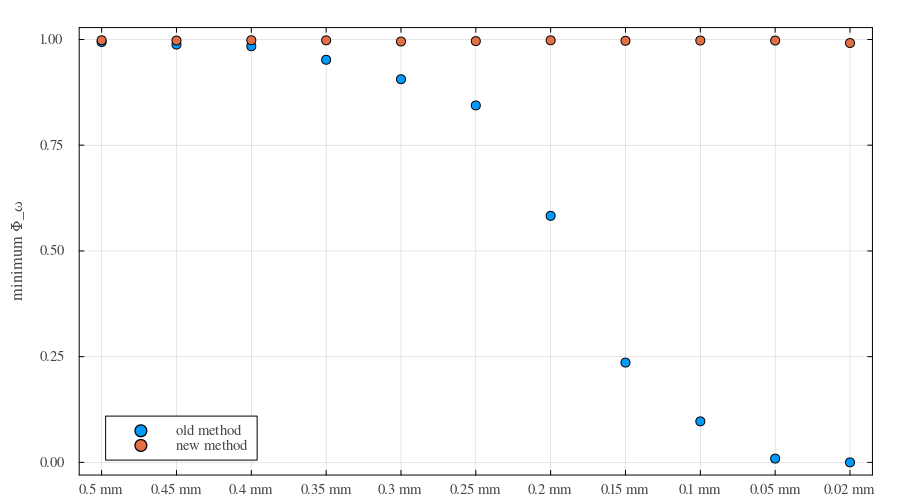

In [137]:
x = 1:length(grid_comp)
labels = string.(grid_comp)

# Plot superiore
plot(
    x,
    wp_old,
    seriestype = :scatter,
    ylabel = "minimum Φ_ω",
    xticks = (x, labels),
    xlabel = "",
    legend = true,
    label = "old method",
    top_margin = 5mm,       # solo margine superiore per bordo
    bottom_margin = 0mm,    # zero margine inferiore per attaccarlo al plot sotto
    left_margin = 5mm,
    right_margin = 5mm,
    framestyle = :box,
    size = (900, 500)
)

plot!(
    x,
    wp_new,
    seriestype = :scatter,
    label = "new method",)



In [ ]:
grid_size = [ 0.02u"mm", 0.01u"mm"]


2-element Vector{Float64}:
 0.9951849
 0.9974032